"Streaming, redes sociales y conciertos: construcción empírica del éxito de un artista musical"
Autora Silvana Contreras
Mayo 2026


In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn jupyter


In [2]:
import pandas as pd
import numpy as np

In [ ]:
from pathlib import Path

# ============================================================
# Directorio único de guardado de gráficos y tablas del proyecto
# ============================================================

directorio_salidas_proyecto = Path(
    r"C:\Users\Silvana\Documents\Maestria_Exactas\taller_tesis_1\music_industry_social_live_code\graficos"
)

directorio_salidas_proyecto.mkdir(
    parents=True,
    exist_ok=True
)

print("Directorio de salida:", directorio_salidas_proyecto)
print("Existe:", directorio_salidas_proyecto.exists())


# ejemplo uso
# ruta_grafico_ranking_editorial = (
#     directorio_salidas_proyecto /
#     "ranking_editorial_lifts_top_bottom_trios.png"
# )

# plt.savefig(
#     ruta_grafico_ranking_editorial,
#     dpi=300,
#     bbox_inches="tight"
# )

# levanto dataset

In [ ]:
from pathlib import Path
import pandas as pd

# df = pd.read_csv("dataset_4913_53.csv") # sin nulos en variable target
df = pd.read_csv("dataset_7000_53.csv") # incluye 2000+ nulos en variable target

print("Dimensiones:", df.shape)


Dimensiones: (7000, 53)


# dimensiones variables

In [4]:
# ============================================================
# Paso 2. Agrupación conceptual de variables
# Construcción de diccionario de variables
# ============================================================

id_cols = [
    "chartmetric_id",
    "artist_name"
]

metadata_cols = [
    "country",
    "country_short",
    "pronoun_title",
    "pronoun_short",
    "record_label",
    "major_record_label",
    "primary_genre",
    "genre_short",
    "band",
    "muerto_disuelto"
]

streaming_cols = [
    "sp_followers",
    "sp_monthly_listeners",
    "sp_popularity",
    "deezer_fans",
    "shazam_count",
    "pandora_lifetime_streams",
    "pandora_lifetime_stations_added"
]

playlist_cols = [
    "sp_playlist_total_reach",
    "num_sp_editorial_playlists",
    "num_sp_playlists",
    "sp_editorial_playlist_total_reach",
    "num_am_editorial_playlists",
    "num_am_playlists",
    "num_de_editorial_playlists",
    "num_de_playlists",
    "de_playlist_total_reach",
    "de_editorial_playlist_total_reach",
    "num_az_editorial_playlists",
    "num_az_playlists",
    "num_yt_editorial_playlists",
    "num_yt_playlists",
    "yt_playlist_total_reach"
]

social_cols = [
    "ins_followers",
    "twitter_followers",
    "tiktok_followers",
    "tiktok_likes",
    "tiktok_top_video_views",
    "tiktok_top_video_comments",
    "tiktok_track_posts"
]

youtube_cols = [
    "ycs_subscribers",
    "ycs_views",
    "youtube_daily_video_views",
    "youtube_monthly_video_views"
]

live_cols = [
    "n_shows_24_25",
    "n_shows_with_capacity_24_25",
    "capacity_24_25",
    "avg_venue_capacity_24_25",
    "n_cities_24_25",
    "n_countries_24_25",
    "shows_per_country_24_25",
    "off_cycle"
]

# Diccionario de dimensiones
column_groups = {
    "identificacion": id_cols,
    "metadata": metadata_cols,
    "streaming": streaming_cols,
    "playlists": playlist_cols,
    "redes_sociales": social_cols,
    "youtube": youtube_cols,
    "live_events": live_cols
}

# ============================================================
# Tabla auxiliar con identidad conceptual de cada variable
# ============================================================

variable_dimension = []

for dimension, cols in column_groups.items():
    for col in cols:
        variable_dimension.append({
            "variable": col,
            "dimension": dimension
        })

df_variable_dimension = pd.DataFrame(variable_dimension)

# ============================================================
# Control de cobertura de columnas
# ============================================================

grouped_cols = df_variable_dimension["variable"].tolist()

cols_in_groups_not_in_df = sorted(set(grouped_cols) - set(df.columns))
cols_in_df_not_in_groups = sorted(set(df.columns) - set(grouped_cols))

print("Columnas del df:", df.shape[1])
print("Columnas agrupadas:", len(grouped_cols))
print("Columnas agrupadas que no están en df:", cols_in_groups_not_in_df)
print("Columnas del df no agrupadas:", cols_in_df_not_in_groups)

# ============================================================
# Resumen por dimensión
# ============================================================

resumen_dimensiones = (
    df_variable_dimension
    .groupby("dimension", as_index=False)
    .agg(n_variables=("variable", "count"))
    .sort_values("n_variables", ascending=False)
)

display(resumen_dimensiones)

# ============================================================
# Vista del diccionario de variables
# ============================================================

display(df_variable_dimension)

Columnas del df: 53
Columnas agrupadas: 53
Columnas agrupadas que no están en df: []
Columnas del df no agrupadas: []


,dimension,n_variables
3,playlists,15
2,metadata,10
1,live_events,8
5,streaming,7
4,redes_sociales,7
6,youtube,4
0,identificacion,2


,variable,dimension
0,chartmetric_id,identificacion
1,artist_name,identificacion
2,country,metadata
3,country_short,metadata
4,pronoun_title,metadata
5,pronoun_short,metadata
6,record_label,metadata
7,major_record_label,metadata
8,primary_genre,metadata
9,genre_short,metadata


# tipos datos

In [5]:
#recupero de la notebook previa

In [6]:
# 1. Definir el diccionario de tipos basado en tu info
dtypes_dict = {
    'chartmetric_id': 'Int64',
    'artist_name': 'str',
    'country': 'category',
    'pronoun_title': 'category',
    'record_label': 'category',
    'primary_genre': 'category',
    'sp_followers': 'Int64',
    'sp_monthly_listeners': 'Int64',
    'sp_popularity': 'float64',
    'sp_playlist_total_reach': 'float64',
    'ins_followers': 'Int64',
    'twitter_followers': 'Int64',
    'tiktok_followers': 'Int64',
    'tiktok_likes': 'Int64',
    'ycs_subscribers': 'Int64',
    'ycs_views': 'Int64',
    'youtube_daily_video_views': 'Int64',
    'youtube_monthly_video_views': 'Int64',
    'deezer_fans': 'Int64',
    'shazam_count': 'Int64',
    'pandora_lifetime_streams': 'Int64',
    'pandora_lifetime_stations_added': 'Int64',
    'band': 'bool',
    'num_sp_editorial_playlists': 'Int64',
    'num_sp_playlists': 'Int64',
    'sp_editorial_playlist_total_reach': 'float64',
    'num_am_editorial_playlists': 'Int64',
    'num_am_playlists': 'Int64',
    'num_de_editorial_playlists': 'Int64',
    'num_de_playlists': 'Int64',
    'de_playlist_total_reach': 'float64',
    'de_editorial_playlist_total_reach': 'float64',
    'num_az_editorial_playlists': 'Int64',
    'num_az_playlists': 'Int64',
    'num_yt_editorial_playlists': 'Int64',
    'num_yt_playlists': 'Int64',
    'yt_playlist_total_reach': 'float64',
    'tiktok_top_video_views': 'float64',
    'tiktok_top_video_comments': 'float64',
    'tiktok_track_posts': 'float64',
    'n_shows_24_25': 'Int64',
    'n_shows_with_capacity_24_25': 'Int64',
    'capacity_24_25': 'float64',
    'avg_venue_capacity_24_25': 'float64',
    'n_cities_24_25': 'Int64',
    'n_countries_24_25': 'Int64',
    'shows_per_country_24_25': 'float64',
    'major_record_label': 'boolean',
    'pronoun_short': 'category',
    'genre_short': 'category',
    'country_short': 'category',
    'off_cycle': 'bool',
    'muerto_disuelto': 'boolean'
}

# 2. Aplicar la conversión al dataframe df
# Código original que podía ocultar conversiones no aplicadas:
# df = df.astype(dtypes_dict, errors='ignore')

# Conversión solo de columnas existentes
dtypes_presentes = {
    col: dtype
    for col, dtype in dtypes_dict.items()
    if col in df.columns
}

df = df.astype(dtypes_presentes)

# 3. Verificación rápida
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 53 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   chartmetric_id                     7000 non-null   Int64   
 1   artist_name                        7000 non-null   str     
 2   country                            6933 non-null   category
 3   pronoun_title                      7000 non-null   category
 4   record_label                       6476 non-null   category
 5   primary_genre                      7000 non-null   category
 6   sp_followers                       6978 non-null   Int64   
 7   sp_monthly_listeners               6978 non-null   Int64   
 8   sp_popularity                      6992 non-null   float64 
 9   sp_playlist_total_reach            6989 non-null   float64 
 10  ins_followers                      6394 non-null   Int64   
 11  twitter_followers                  5227 non-null   Int

In [7]:
# Estructura general del dataset
print("Filas y columnas:", df.shape)

# Control de clave única
print("Artistas únicos:", df["chartmetric_id"].nunique())
print("Duplicados por chartmetric_id:", df.duplicated(subset="chartmetric_id").sum())

# Control de target
print("Nulos en target:", df["n_shows_24_25"].isna().sum())
print("Tipo de dato de target:", df["n_shows_24_25"].dtype)

Filas y columnas: (7000, 53)
Artistas únicos: 7000
Duplicados por chartmetric_id: 0
Nulos en target: 2087
Tipo de dato de target: Int64


# multicolinealidad
sin target

In [8]:
# ============================================================
# Pares de variables digitales altamente correlacionadas
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Parámetros
# ------------------------------------------------------------

umbral_corr = 0.70

df_multi = df.copy()

# ------------------------------------------------------------
# Variables digitales candidatas
# Se usan solo variables digitales numéricas efectivamente presentes en el dataframe
# ------------------------------------------------------------

digital_cols = (
    streaming_cols
    + playlist_cols
    + social_cols
    + youtube_cols
)

digital_numeric_vars = [
    col for col in digital_cols
    if col in df_multi.columns and pd.api.types.is_numeric_dtype(df_multi[col])
]

print("Variables digitales candidatas:", len(digital_cols))
print("Variables digitales numéricas disponibles:", len(digital_numeric_vars))

# ------------------------------------------------------------
# Transformación log1p para variables digitales no acotadas
# sp_popularity se conserva en escala original por estar acotada entre 0 y 100
# ------------------------------------------------------------

vars_log = [
    col for col in digital_numeric_vars
    if col != "sp_popularity"
]

for col in vars_log:
    df_multi[f"log1p_{col}"] = np.log1p(df_multi[col].astype(float))

vars_multi = [f"log1p_{col}" for col in vars_log]

if "sp_popularity" in digital_numeric_vars:
    vars_multi = vars_multi + ["sp_popularity"]

# ------------------------------------------------------------
# Matriz de correlación entre variables digitales
# ------------------------------------------------------------

corr_matrix = df_multi[vars_multi].corr(method="pearson")

corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["variable_1", "variable_2", "correlacion_entre_vars"]

corr_pairs["abs_correlacion_entre_vars"] = corr_pairs["correlacion_entre_vars"].abs()

corr_pairs_altas = (
    corr_pairs
    .loc[corr_pairs["abs_correlacion_entre_vars"] >= umbral_corr]
    .sort_values("abs_correlacion_entre_vars", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Funciones auxiliares para recuperar variable original y dimensión
# ------------------------------------------------------------

def quitar_log1p(variable):
    return variable.replace("log1p_", "")

def asignar_dimension(variable):
    if variable in streaming_cols:
        return "streaming"
    elif variable in playlist_cols:
        return "playlists"
    elif variable in social_cols:
        return "redes_sociales"
    elif variable in youtube_cols:
        return "youtube"
    else:
        return "otra"

corr_pairs_altas["var1_original"] = corr_pairs_altas["variable_1"].apply(quitar_log1p)
corr_pairs_altas["var2_original"] = corr_pairs_altas["variable_2"].apply(quitar_log1p)

corr_pairs_altas["dimension_1"] = corr_pairs_altas["var1_original"].apply(asignar_dimension)
corr_pairs_altas["dimension_2"] = corr_pairs_altas["var2_original"].apply(asignar_dimension)

# ------------------------------------------------------------
# Porcentaje de nulos por variable
# ------------------------------------------------------------

null_pct_lookup = (
    df_multi[digital_numeric_vars]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .to_dict()
)

corr_pairs_altas["pct_null_var1"] = corr_pairs_altas["var1_original"].map(null_pct_lookup)
corr_pairs_altas["pct_null_var2"] = corr_pairs_altas["var2_original"].map(null_pct_lookup)

# ------------------------------------------------------------
# Selección de columnas para revisión
# ------------------------------------------------------------

corr_pairs_altas = corr_pairs_altas[
    [
        "var1_original",
        "var2_original",
        "dimension_1",
        "dimension_2",
        "correlacion_entre_vars",
        "abs_correlacion_entre_vars",
        "pct_null_var1",
        "pct_null_var2"
    ]
].round({
    "correlacion_entre_vars": 3,
    "abs_correlacion_entre_vars": 3,
    "pct_null_var1": 2,
    "pct_null_var2": 2
})

pd.set_option("display.max_rows", 150)
pd.set_option("display.min_rows", 150)

corr_pairs_altas


Variables digitales candidatas: 33
Variables digitales numéricas disponibles: 33


,var1_original,var2_original,dimension_1,dimension_2,correlacion_entre_vars,abs_correlacion_entre_vars,pct_null_var1,pct_null_var2
0,num_az_editorial_playlists,num_az_playlists,playlists,playlists,0.996,0.996,11.41,11.41
1,tiktok_top_video_views,tiktok_top_video_comments,redes_sociales,redes_sociales,0.975,0.975,0.94,0.94
2,num_am_editorial_playlists,num_am_playlists,playlists,playlists,0.949,0.949,3.23,3.23
3,sp_monthly_listeners,sp_popularity,streaming,streaming,0.935,0.935,0.31,0.11
4,pandora_lifetime_streams,pandora_lifetime_stations_added,streaming,streaming,0.934,0.934,6.71,9.57
5,tiktok_followers,tiktok_likes,redes_sociales,redes_sociales,0.927,0.927,31.41,31.41
6,tiktok_top_video_views,tiktok_track_posts,redes_sociales,redes_sociales,0.925,0.925,0.94,0.96
7,tiktok_top_video_comments,tiktok_track_posts,redes_sociales,redes_sociales,0.922,0.922,0.94,0.96
8,sp_playlist_total_reach,num_sp_playlists,playlists,playlists,0.920,0.920,0.16,0.16
9,shazam_count,num_sp_playlists,streaming,playlists,0.888,0.888,0.24,0.16


In [9]:
# ============================================================
# Variables más involucradas en pares altamente correlacionados
# ============================================================

# ------------------------------------------------------------
# Tabla larga con una fila por variable dentro de cada par
# ------------------------------------------------------------

vars_en_pares_1 = corr_pairs_altas[
    [
        "var1_original",
        "dimension_1",
        "abs_correlacion_entre_vars",
        "pct_null_var1"
    ]
].copy()

vars_en_pares_1.columns = [
    "variable",
    "dimension",
    "abs_correlacion_entre_vars",
    "pct_null"
]

vars_en_pares_2 = corr_pairs_altas[
    [
        "var2_original",
        "dimension_2",
        "abs_correlacion_entre_vars",
        "pct_null_var2"
    ]
].copy()

vars_en_pares_2.columns = [
    "variable",
    "dimension",
    "abs_correlacion_entre_vars",
    "pct_null"
]

vars_en_pares = pd.concat(
    [vars_en_pares_1, vars_en_pares_2],
    ignore_index=True
)

# ------------------------------------------------------------
# Resumen por variable
# ------------------------------------------------------------

redundancia_por_variable = (
    vars_en_pares
    .groupby(["variable", "dimension"])
    .agg(
        n_pares_altos=("abs_correlacion_entre_vars", "count"),
        max_corr_con_otra_var=("abs_correlacion_entre_vars", "max"),
        corr_media_con_otras_vars=("abs_correlacion_entre_vars", "mean"),
        pct_null=("pct_null", "first")
    )
    .reset_index()
)

redundancia_por_variable = (
    redundancia_por_variable
    .sort_values(
        ["n_pares_altos", "max_corr_con_otra_var", "pct_null"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

redundancia_por_variable = redundancia_por_variable.round({
    "max_corr_con_otra_var": 3,
    "corr_media_con_otras_vars": 3,
    "pct_null": 2
})

redundancia_por_variable

,variable,dimension,n_pares_altos,max_corr_con_otra_var,corr_media_con_otras_vars,pct_null
0,num_sp_editorial_playlists,playlists,13,0.857,0.765,0.16
1,sp_playlist_total_reach,playlists,12,0.920,0.793,0.16
2,num_am_playlists,playlists,11,0.949,0.792,3.23
3,num_am_editorial_playlists,playlists,10,0.949,0.764,3.23
4,num_sp_playlists,playlists,10,0.920,0.792,0.16
5,num_de_playlists,playlists,8,0.877,0.761,7.76
6,sp_popularity,streaming,7,0.935,0.793,0.11
7,shazam_count,streaming,7,0.888,0.786,0.24
8,sp_monthly_listeners,streaming,6,0.935,0.806,0.31
9,num_de_editorial_playlists,playlists,6,0.877,0.772,7.76


In [10]:
# ============================================================
# Exportación de tablas de redundancia para revisión
# ============================================================

archivo_redundancia_clustering = "salidas_redundancia_clustering.xlsx"

with pd.ExcelWriter(archivo_redundancia_clustering) as writer:
    corr_pairs_altas.to_excel(
        writer,
        sheet_name="pares_correlacionados",
        index=False
    )
    
    redundancia_por_variable.to_excel(
        writer,
        sheet_name="redundancia_variable",
        index=False
    )

archivo_redundancia_clustering

'salidas_redundancia_clustering.xlsx'

# grafico pares redundancias conservadas


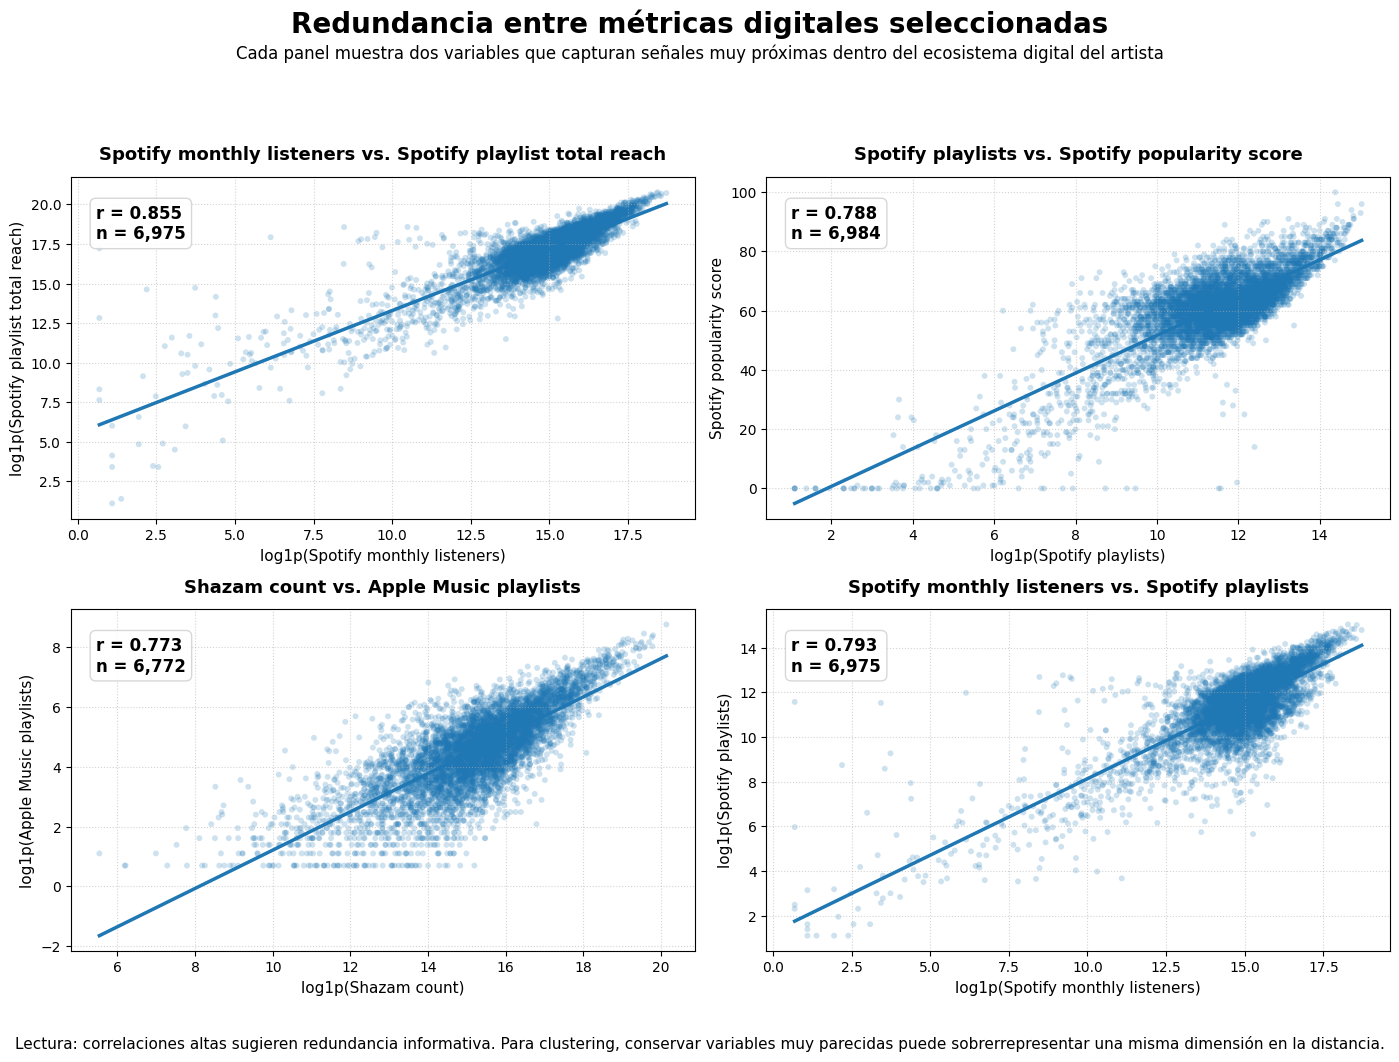

'grafico_redundancia_pares_clustering.png'

In [11]:
# ============================================================
# Gráfico ejecutivo de redundancia entre pares de variables
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Pares de variables a visualizar
# ------------------------------------------------------------

pares_redundancia = [
    ("sp_monthly_listeners", "sp_playlist_total_reach"),
    ("num_sp_playlists", "sp_popularity"),
    ("shazam_count", "num_am_playlists"),
    ("sp_monthly_listeners", "num_sp_playlists")
]

# ------------------------------------------------------------
# Etiquetas legibles para el gráfico
# ------------------------------------------------------------

etiquetas_variables = {
    "sp_monthly_listeners": "Spotify monthly listeners",
    "sp_playlist_total_reach": "Spotify playlist total reach",
    "num_sp_playlists": "Spotify playlists",
    "sp_popularity": "Spotify popularity score",
    "shazam_count": "Shazam count",
    "num_am_playlists": "Apple Music playlists"
}

# ------------------------------------------------------------
# Función auxiliar para transformar variables
# sp_popularity se conserva en escala original por estar acotada entre 0 y 100
# ------------------------------------------------------------

def transformar_variable_para_grafico(serie, nombre_variable):
    serie = serie.astype(float)
    
    if nombre_variable == "sp_popularity":
        return serie
    
    return np.log1p(serie)

# ------------------------------------------------------------
# Función auxiliar para etiqueta de eje
# ------------------------------------------------------------

def etiqueta_eje(nombre_variable):
    etiqueta = etiquetas_variables.get(nombre_variable, nombre_variable)
    
    if nombre_variable == "sp_popularity":
        return etiqueta
    
    return f"log1p({etiqueta})"

# ------------------------------------------------------------
# Configuración general del gráfico
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 11)
)

axes = axes.flatten()

fig.suptitle(
    "Redundancia entre métricas digitales seleccionadas",
    fontsize=20,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.935,
    "Cada panel muestra dos variables que capturan señales muy próximas dentro del ecosistema digital del artista",
    ha="center",
    fontsize=12
)

# ------------------------------------------------------------
# Construcción de paneles
# ------------------------------------------------------------

for ax, (var_x, var_y) in zip(axes, pares_redundancia):
    
    df_par = df[[var_x, var_y]].copy()
    df_par = df_par.dropna()
    
    x = transformar_variable_para_grafico(df_par[var_x], var_x)
    y = transformar_variable_para_grafico(df_par[var_y], var_y)
    
    datos_plot = pd.DataFrame({
        "x": x,
        "y": y
    }).replace([np.inf, -np.inf], np.nan).dropna()
    
    x = datos_plot["x"]
    y = datos_plot["y"]
    
    correlacion = x.corr(y, method="pearson")
    
    ax.scatter(
        x,
        y,
        s=18,
        alpha=0.22,
        edgecolors="none"
    )
    
    if len(datos_plot) > 2:
        pendiente, intercepto = np.polyfit(x, y, 1)
        x_linea = np.linspace(x.min(), x.max(), 100)
        y_linea = pendiente * x_linea + intercepto
        
        ax.plot(
            x_linea,
            y_linea,
            linewidth=2.5
        )
    
    ax.set_title(
        f"{etiquetas_variables.get(var_x, var_x)} vs. {etiquetas_variables.get(var_y, var_y)}",
        fontsize=13,
        fontweight="bold",
        pad=12
    )
    
    ax.set_xlabel(
        etiqueta_eje(var_x),
        fontsize=11
    )
    
    ax.set_ylabel(
        etiqueta_eje(var_y),
        fontsize=11
    )
    
    ax.text(
        0.04,
        0.92,
        f"r = {correlacion:.3f}\nn = {len(datos_plot):,}",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="lightgray",
            alpha=0.9
        )
    )
    
    ax.grid(
        True,
        linestyle=":",
        linewidth=0.8,
        alpha=0.55
    )

# ------------------------------------------------------------
# Nota metodológica
# ------------------------------------------------------------

fig.text(
    0.5,
    0.035,
    "Lectura: correlaciones altas sugieren redundancia informativa. Para clustering, conservar variables muy parecidas puede sobrerrepresentar una misma dimensión en la distancia.",
    ha="center",
    fontsize=11
)

plt.tight_layout(rect=[0.03, 0.07, 0.97, 0.91])

# ------------------------------------------------------------
# Guardado del gráfico
# ------------------------------------------------------------

archivo_grafico_redundancia = "grafico_redundancia_pares_clustering.png"

plt.savefig(
    archivo_grafico_redundancia,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

archivo_grafico_redundancia

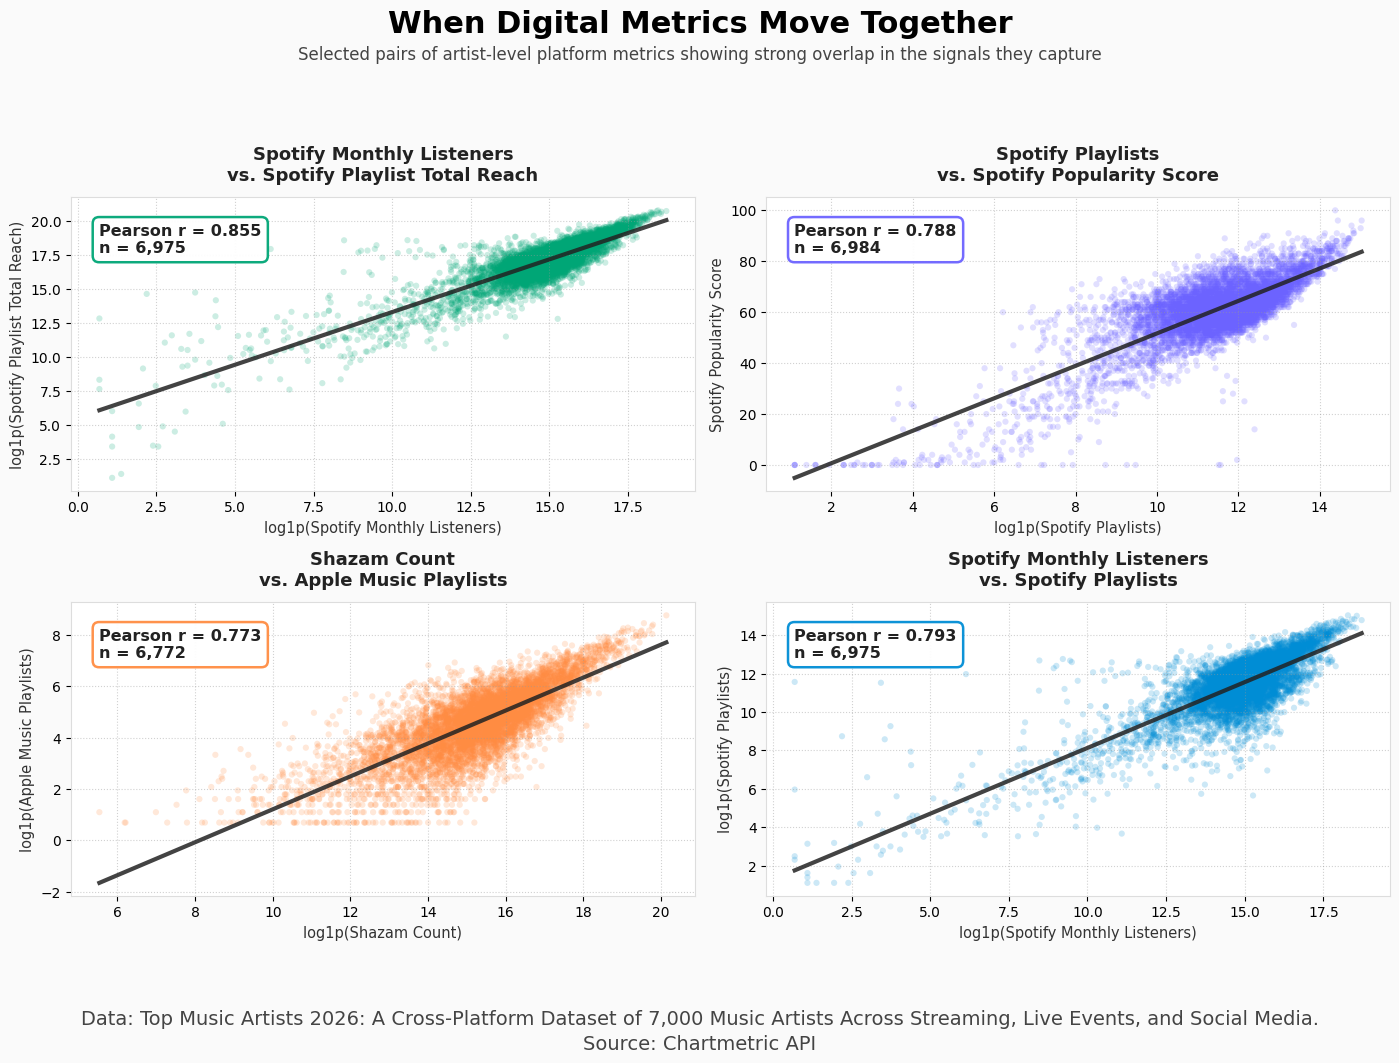

'digital_metric_redundancy_pairs.png'

In [12]:
# ============================================================
# Executive visualization of redundancy between digital metrics
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Pairs of variables to visualize
# ------------------------------------------------------------

metric_pairs = [
    ("sp_monthly_listeners", "sp_playlist_total_reach"),
    ("num_sp_playlists", "sp_popularity"),
    ("shazam_count", "num_am_playlists"),
    ("sp_monthly_listeners", "num_sp_playlists")
]

# ------------------------------------------------------------
# Human-readable labels
# ------------------------------------------------------------

metric_labels = {
    "sp_monthly_listeners": "Spotify Monthly Listeners",
    "sp_playlist_total_reach": "Spotify Playlist Total Reach",
    "num_sp_playlists": "Spotify Playlists",
    "sp_popularity": "Spotify Popularity Score",
    "shazam_count": "Shazam Count",
    "num_am_playlists": "Apple Music Playlists"
}

# ------------------------------------------------------------
# Colors by panel
# ------------------------------------------------------------

panel_colors = [
    "#00A676",  # green
    "#6C63FF",  # violet
    "#FF8C42",  # orange
    "#008DD5"   # blue
]

# ------------------------------------------------------------
# Transformation helper
# sp_popularity remains in its original scale because it is bounded from 0 to 100
# ------------------------------------------------------------

def transform_metric(series, metric_name):
    series = series.astype(float)
    
    if metric_name == "sp_popularity":
        return series
    
    return np.log1p(series)

# ------------------------------------------------------------
# Axis label helper
# ------------------------------------------------------------

def axis_label(metric_name):
    label = metric_labels.get(metric_name, metric_name)
    
    if metric_name == "sp_popularity":
        return label
    
    return f"log1p({label})"

# ------------------------------------------------------------
# General figure setup
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 11)
)

axes = axes.flatten()

fig.patch.set_facecolor("#FAFAFA")

fig.suptitle(
    "When Digital Metrics Move Together",
    fontsize=22,
    fontweight="bold",
    y=0.98
)

fig.text(
    0.5,
    0.935,
    "Selected pairs of artist-level platform metrics showing strong overlap in the signals they capture",
    ha="center",
    fontsize=12,
    color="#444444"
)

# ------------------------------------------------------------
# Panel construction
# ------------------------------------------------------------

for ax, (var_x, var_y), color in zip(axes, metric_pairs, panel_colors):
    
    df_pair = df[[var_x, var_y]].copy()
    df_pair = df_pair.dropna()
    
    x = transform_metric(df_pair[var_x], var_x)
    y = transform_metric(df_pair[var_y], var_y)
    
    plot_data = pd.DataFrame({
        "x": x,
        "y": y
    }).replace([np.inf, -np.inf], np.nan).dropna()
    
    x = plot_data["x"]
    y = plot_data["y"]
    
    correlation = x.corr(y, method="pearson")
    
    ax.set_facecolor("#FFFFFF")
    
    ax.scatter(
        x,
        y,
        s=20,
        alpha=0.20,
        color=color,
        edgecolors="none"
    )
    
    if len(plot_data) > 2:
        slope, intercept = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = slope * x_line + intercept
        
        ax.plot(
            x_line,
            y_line,
            linewidth=3,
            color="#222222",
            alpha=0.85
        )
    
    ax.set_title(
        f"{metric_labels.get(var_x, var_x)}\nvs. {metric_labels.get(var_y, var_y)}",
        fontsize=13,
        fontweight="bold",
        pad=12,
        color="#222222"
    )
    
    ax.set_xlabel(
        axis_label(var_x),
        fontsize=10.5,
        color="#333333"
    )
    
    ax.set_ylabel(
        axis_label(var_y),
        fontsize=10.5,
        color="#333333"
    )
    
    ax.text(
        0.045,
        0.91,
        f"Pearson r = {correlation:.3f}\nn = {len(plot_data):,}",
        transform=ax.transAxes,
        fontsize=11.5,
        fontweight="bold",
        va="top",
        color="#222222",
        bbox=dict(
            boxstyle="round,pad=0.40",
            facecolor="#FFFFFF",
            edgecolor=color,
            linewidth=1.8,
            alpha=0.95
        )
    )
    
    ax.grid(
        True,
        linestyle=":",
        linewidth=0.8,
        alpha=0.45,
        color="#999999"
    )
    
    for spine in ax.spines.values():
        spine.set_color("#DDDDDD")

# ------------------------------------------------------------
# Explanatory note
# ------------------------------------------------------------

# fig.text(
#     0.5,
#     0.035,
#     "Reading guide: high correlations indicate that two metrics are capturing very similar artist-level signals, even when they come from different platform features. /n Data: Top Music Artists 2026: A Cross-Platform Dataset of 7,000 Music Artists Across Streaming, Live Events, and Social Media",
#     ha="center",
#     fontsize=11,
#     color="#444444"
# )

fig.text(
    0.5,
    0.035,
    "Data: Top Music Artists 2026: A Cross-Platform Dataset of 7,000 Music Artists Across Streaming, Live Events, and Social Media.\n"
    "Source: Chartmetric API",
    ha="center",
    fontsize=14,
    color="#444444",
    linespacing=1.35
)

# plt.tight_layout(rect=[0.03, 0.07, 0.97, 0.91])

plt.tight_layout(rect=[0.03, 0.12, 0.97, 0.91])

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

redundancy_chart_file = "digital_metric_redundancy_pairs.png"

plt.savefig(
    redundancy_chart_file,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

redundancy_chart_file

# nulos e imput para lineal

In [13]:
# # ------------------------------------------------------------
# # Diagnóstico de nulos antes de ajustar regresión lineal
# # ------------------------------------------------------------

# resumen_nulos_modelo = (
#     df_modelo_lineal
#     .isna()
#     .sum()
#     .reset_index()
# )

# resumen_nulos_modelo.columns = ["variable", "n_null"]

# resumen_nulos_modelo["pct_null"] = (
#     resumen_nulos_modelo["n_null"] / len(df_modelo_lineal) * 100
# ).round(2)

# resumen_nulos_modelo = (
#     resumen_nulos_modelo
#     .sort_values("pct_null", ascending=False)
#     .reset_index(drop=True)
# )

# display(resumen_nulos_modelo)

# # ------------------------------------------------------------
# # Registros completos por bloque
# # ------------------------------------------------------------

# columnas_numericas_modelo = [
#     "log1p_n_shows_24_25"
# ] + variables_regresion_final_log

# columnas_categoricas_modelo = categoricas_regresion.copy()

# n_total = df_modelo_lineal.shape[0]

# n_completo_numericas = (
#     df_modelo_lineal[columnas_numericas_modelo]
#     .dropna()
#     .shape[0]
# )

# n_completo_categoricas = (
#     df_modelo_lineal[columnas_categoricas_modelo]
#     .dropna()
#     .shape[0]
# )

# n_completo_total = df_modelo_lineal.dropna().shape[0]

# print("Artistas iniciales:", n_total)

# print(
#     "Artistas completos en variables numéricas:",
#     n_completo_numericas,
#     "| porcentaje:",
#     round(n_completo_numericas / n_total * 100, 2)
# )

# print(
#     "Artistas completos en variables categóricas:",
#     n_completo_categoricas,
#     "| porcentaje:",
#     round(n_completo_categoricas / n_total * 100, 2)
# )

# print(
#     "Artistas completos en todo el set de modelado:",
#     n_completo_total,
#     "| porcentaje:",
#     round(n_completo_total / n_total * 100, 2)
# )

# print(
#     "Artistas que se perderían si se aplica dropna total:",
#     n_total - n_completo_total
# )

In [14]:
# # ------------------------------------------------------------
# # Tratamiento de nulos para regresión lineal
# # ------------------------------------------------------------

# df_modelo_lineal_imp = df_modelo_lineal.copy()

# # ------------------------------------------------------------
# # Variables imputadas con valor sustantivo
# # ------------------------------------------------------------

# df_modelo_lineal_imp["log1p_twitter_followers_imp"] = (
#     df_modelo_lineal_imp["log1p_twitter_followers"]
#     .fillna(0)
# )

# df_modelo_lineal_imp["log1p_ins_followers_imp"] = (
#     df_modelo_lineal_imp["log1p_ins_followers"]
#     .fillna(0)
# )

# df_modelo_lineal_imp["major_record_label_imp"] = (
#     df_modelo_lineal_imp["major_record_label"]
#     .fillna(False)
# )

# # ------------------------------------------------------------
# # Variables copiadas con sufijo _imp para conservar trazabilidad
# # ------------------------------------------------------------

# df_modelo_lineal_imp["log1p_ycs_views_imp"] = df_modelo_lineal_imp["log1p_ycs_views"]
# df_modelo_lineal_imp["log1p_pandora_lifetime_streams_imp"] = df_modelo_lineal_imp["log1p_pandora_lifetime_streams"]
# df_modelo_lineal_imp["log1p_num_yt_editorial_playlists_imp"] = df_modelo_lineal_imp["log1p_num_yt_editorial_playlists"]
# df_modelo_lineal_imp["log1p_deezer_fans_imp"] = df_modelo_lineal_imp["log1p_deezer_fans"]
# df_modelo_lineal_imp["log1p_tiktok_top_video_comments_imp"] = df_modelo_lineal_imp["log1p_tiktok_top_video_comments"]
# df_modelo_lineal_imp["log1p_sp_monthly_listeners_imp"] = df_modelo_lineal_imp["log1p_sp_monthly_listeners"]
# df_modelo_lineal_imp["country_short_imp"] = df_modelo_lineal_imp["country_short"]

# # ------------------------------------------------------------
# # Drop de registros con nulos remanentes
# # ------------------------------------------------------------

# variables_dropna_imp = [
#     "log1p_ycs_views_imp",
#     "log1p_pandora_lifetime_streams_imp",
#     "log1p_num_yt_editorial_playlists_imp",
#     "log1p_deezer_fans_imp",
#     "log1p_tiktok_top_video_comments_imp",
#     "log1p_sp_monthly_listeners_imp",
#     "country_short_imp"
# ]

# n_antes = df_modelo_lineal_imp.shape[0]

# df_modelo_lineal_imp = (
#     df_modelo_lineal_imp
#     .dropna(subset=variables_dropna_imp)
#     .copy()
# )

# n_despues = df_modelo_lineal_imp.shape[0]

# print("Artistas antes del tratamiento:", n_antes)
# print("Artistas después del tratamiento:", n_despues)
# print("Artistas eliminados por nulos remanentes:", n_antes - n_despues)
# print("Porcentaje conservado:", round(n_despues / n_antes * 100, 2))

# # ------------------------------------------------------------
# # Listas finales para modelado
# # ------------------------------------------------------------

# features_numericas_imp = [
#     "log1p_num_yt_editorial_playlists_imp",
#     "log1p_num_sp_playlists",
#     "log1p_ins_followers_imp",
#     "log1p_twitter_followers_imp",
#     "log1p_tiktok_top_video_comments_imp",
#     "log1p_sp_monthly_listeners_imp",
#     "log1p_pandora_lifetime_streams_imp",
#     "log1p_deezer_fans_imp",
#     "log1p_ycs_views_imp"
# ]

# features_categoricas_imp = [
#     "country_short_imp",
#     "genre_short",
#     "pronoun_short",
#     "band",
#     "major_record_label_imp"
# ]

# features_modelo_imp = features_numericas_imp + features_categoricas_imp

# # ------------------------------------------------------------
# # Control final de nulos
# # ------------------------------------------------------------

# resumen_nulos_imp = (
#     df_modelo_lineal_imp[
#         ["log1p_n_shows_24_25"] + features_modelo_imp
#     ]
#     .isna()
#     .sum()
#     .reset_index()
# )

# resumen_nulos_imp.columns = ["variable", "n_null"]

# resumen_nulos_imp["pct_null"] = (
#     resumen_nulos_imp["n_null"] / len(df_modelo_lineal_imp) * 100
# ).round(2)

# display(resumen_nulos_imp)

# selección variables

In [15]:
# ============================================================
# Selección de variables digitales para clustering
# Criterio: representación de dimensiones y reducción de redundancia
# ============================================================

variables_clustering_digitales_base = [
    # Streaming
    "sp_monthly_listeners",
    "sp_followers",
    "deezer_fans",
    "pandora_lifetime_streams",

    # Playlists
    "num_sp_playlists",
    "num_am_playlists",
    "num_yt_editorial_playlists",

    # Redes sociales
    "ins_followers",
    "twitter_followers",
    "tiktok_followers",
    "tiktok_top_video_comments",

    # YouTube
    "ycs_views"
]

variables_clustering_digitales_base = [
    col for col in variables_clustering_digitales_base
    if col in df.columns
]

len(variables_clustering_digitales_base), variables_clustering_digitales_base

(12,
 ['sp_monthly_listeners',
  'sp_followers',
  'deezer_fans',
  'pandora_lifetime_streams',
  'num_sp_playlists',
  'num_am_playlists',
  'num_yt_editorial_playlists',
  'ins_followers',
  'twitter_followers',
  'tiktok_followers',
  'tiktok_top_video_comments',
  'ycs_views'])

# nulos

In [16]:
# ============================================================
# Diagnóstico de valores faltantes en variables de clustering
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Variables activas seleccionadas para clustering
# ------------------------------------------------------------

variables_clustering_digitales_base = [
    # Streaming
    "sp_monthly_listeners",
    "sp_followers",
    "deezer_fans",
    "pandora_lifetime_streams",

    # Playlists
    "num_sp_playlists",
    "num_am_playlists",
    "num_yt_editorial_playlists",

    # Redes sociales
    "ins_followers",
    "twitter_followers",
    "tiktok_followers",
    "tiktok_top_video_comments",

    # YouTube
    "ycs_views"
]

variables_clustering_digitales_base = [
    col for col in variables_clustering_digitales_base
    if col in df.columns
]

# ------------------------------------------------------------
# Tabla de nulos por variable
# ------------------------------------------------------------

tabla_nulos_clustering = (
    df[variables_clustering_digitales_base]
    .isna()
    .agg(["sum", "mean"])
    .T
    .reset_index()
)

tabla_nulos_clustering.columns = [
    "variable",
    "n_nulos",
    "pct_nulos"
]

tabla_nulos_clustering["pct_nulos"] = (
    tabla_nulos_clustering["pct_nulos"] * 100
).round(2)

tabla_nulos_clustering = (
    tabla_nulos_clustering
    .sort_values("pct_nulos", ascending=False)
    .reset_index(drop=True)
)

tabla_nulos_clustering

,variable,n_nulos,pct_nulos
0,tiktok_followers,2199.0,31.41
1,twitter_followers,1773.0,25.33
2,ycs_views,619.0,8.84
3,ins_followers,606.0,8.66
4,pandora_lifetime_streams,470.0,6.71
5,num_yt_editorial_playlists,431.0,6.16
6,num_am_playlists,226.0,3.23
7,deezer_fans,198.0,2.83
8,tiktok_top_video_comments,66.0,0.94
9,sp_followers,22.0,0.31


In [17]:
# ============================================================
# Cobertura de casos completos en matriz de clustering
# ============================================================

n_total_artistas = len(df)

n_artistas_completos = (
    df[variables_clustering_digitales_base]
    .notna()
    .all(axis=1)
    .sum()
)

pct_artistas_completos = round(
    n_artistas_completos / n_total_artistas * 100,
    2
)

resumen_cobertura_clustering = pd.DataFrame({
    "indicador": [
        "artistas_totales",
        "artistas_sin_nulos_en_variables_clustering",
        "porcentaje_sin_nulos"
    ],
    "valor": [
        n_total_artistas,
        n_artistas_completos,
        pct_artistas_completos
    ]
})

resumen_cobertura_clustering

,indicador,valor
0,artistas_totales,7000.00
1,artistas_sin_nulos_en_variables_clustering,3651.00
2,porcentaje_sin_nulos,52.16


In [18]:
# ============================================================
# Cantidad de variables faltantes por artista
# ============================================================

nulos_por_artista_clustering = (
    df[variables_clustering_digitales_base]
    .isna()
    .sum(axis=1)
)

distribucion_nulos_por_artista = (
    nulos_por_artista_clustering
    .value_counts()
    .sort_index()
    .reset_index()
)

distribucion_nulos_por_artista.columns = [
    "n_variables_faltantes",
    "n_artistas"
]

distribucion_nulos_por_artista["pct_artistas"] = (
    distribucion_nulos_por_artista["n_artistas"] / len(df) * 100
).round(2)

distribucion_nulos_por_artista

,n_variables_faltantes,n_artistas,pct_artistas
0,0,3651,52.16
1,1,1741,24.87
2,2,764,10.91
3,3,416,5.94
4,4,227,3.24
5,5,100,1.43
6,6,42,0.60
7,7,28,0.40
8,8,16,0.23
9,9,10,0.14


# imputación 
0 y flags

In [19]:
# ============================================================
# Tratamiento de nulos para matriz de clustering digital
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Variables activas seleccionadas para clustering
# ------------------------------------------------------------

variables_clustering_digitales_base = [
    # Streaming
    "sp_monthly_listeners",
    "sp_followers",
    "deezer_fans",
    "pandora_lifetime_streams",

    # Playlists
    "num_sp_playlists",
    "num_am_playlists",
    "num_yt_editorial_playlists",

    # Redes sociales
    "ins_followers",
    "twitter_followers",
    "tiktok_followers",
    "tiktok_top_video_comments",

    # YouTube
    "ycs_views"
]

variables_clustering_digitales_base = [
    col for col in variables_clustering_digitales_base
    if col in df.columns
]

df_clustering = df.copy()

# ------------------------------------------------------------
# Variables con faltantes relevantes
# Los indicadores conservan información sobre ausencia de dato original
# ------------------------------------------------------------

variables_con_flag_missing = [
    "tiktok_followers",
    "twitter_followers",
    "ins_followers",
    "ycs_views"
]

variables_con_flag_missing = [
    col for col in variables_con_flag_missing
    if col in variables_clustering_digitales_base
]

for col in variables_con_flag_missing:
    df_clustering[f"missing_{col}"] = df_clustering[col].isna().astype(int)

# ------------------------------------------------------------
# Imputación con 0 en variables digitales seleccionadas
# ------------------------------------------------------------

df_clustering[variables_clustering_digitales_base] = (
    df_clustering[variables_clustering_digitales_base]
    .fillna(0)
)

# ------------------------------------------------------------
# Control posterior de nulos
# ------------------------------------------------------------

control_nulos_post_imputacion = (
    df_clustering[variables_clustering_digitales_base]
    .isna()
    .sum()
    .reset_index()
)

control_nulos_post_imputacion.columns = [
    "variable",
    "n_nulos_post_imputacion"
]

control_nulos_post_imputacion

,variable,n_nulos_post_imputacion
0,sp_monthly_listeners,0
1,sp_followers,0
2,deezer_fans,0
3,pandora_lifetime_streams,0
4,num_sp_playlists,0
5,num_am_playlists,0
6,num_yt_editorial_playlists,0
7,ins_followers,0
8,twitter_followers,0
9,tiktok_followers,0


In [20]:
# ============================================================
# Variables activas finales para clustering
# Incluyen variables digitales imputadas e indicadores de faltante
# ============================================================

missing_cols_clustering = [
    f"missing_{col}"
    for col in variables_con_flag_missing
]

variables_clustering_activas = (
    variables_clustering_digitales_base
    + missing_cols_clustering
)

variables_clustering_activas

['sp_monthly_listeners',
 'sp_followers',
 'deezer_fans',
 'pandora_lifetime_streams',
 'num_sp_playlists',
 'num_am_playlists',
 'num_yt_editorial_playlists',
 'ins_followers',
 'twitter_followers',
 'tiktok_followers',
 'tiktok_top_video_comments',
 'ycs_views',
 'missing_tiktok_followers',
 'missing_twitter_followers',
 'missing_ins_followers',
 'missing_ycs_views']

In [21]:
len(variables_clustering_activas), variables_clustering_activas

(16,
 ['sp_monthly_listeners',
  'sp_followers',
  'deezer_fans',
  'pandora_lifetime_streams',
  'num_sp_playlists',
  'num_am_playlists',
  'num_yt_editorial_playlists',
  'ins_followers',
  'twitter_followers',
  'tiktok_followers',
  'tiktok_top_video_comments',
  'ycs_views',
  'missing_tiktok_followers',
  'missing_twitter_followers',
  'missing_ins_followers',
  'missing_ycs_views'])

# transformación y escalado

In [22]:
# ============================================================
# Transformación log1p y matriz de clustering con flags binarios
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Transformación log1p de variables digitales imputadas
# ------------------------------------------------------------

variables_log_clustering = []

for col in variables_clustering_digitales_base:
    col_log = f"log1p_{col}"
    df_clustering[col_log] = np.log1p(df_clustering[col].astype(float))
    variables_log_clustering.append(col_log)

# ------------------------------------------------------------
# Escalado solo de variables digitales transformadas
# ------------------------------------------------------------

scaler_clustering = StandardScaler()

X_metricas_escaladas = pd.DataFrame(
    scaler_clustering.fit_transform(df_clustering[variables_log_clustering]),
    columns=variables_log_clustering,
    index=df_clustering.index
)

# ------------------------------------------------------------
# Flags de faltante conservados como variables binarias 0/1
# ------------------------------------------------------------

X_flags_missing = df_clustering[missing_cols_clustering].astype(int).copy()

# ------------------------------------------------------------
# Matriz final de clustering
# ------------------------------------------------------------

X_clustering = pd.concat(
    [
        X_metricas_escaladas,
        X_flags_missing
    ],
    axis=1
)

# ------------------------------------------------------------
# Controles finales
# ------------------------------------------------------------

print("Filas en X_clustering:", X_clustering.shape[0])
print("Columnas en X_clustering:", X_clustering.shape[1])
print("Nulos en X_clustering:", X_clustering.isna().sum().sum())

display(X_clustering.head())





Filas en X_clustering: 7000
Columnas en X_clustering: 16
Nulos en X_clustering: 0


,log1p_sp_monthly_listeners,log1p_sp_followers,log1p_deezer_fans,log1p_pandora_lifetime_streams,log1p_num_sp_playlists,log1p_num_am_playlists,log1p_num_yt_editorial_playlists,log1p_ins_followers,log1p_twitter_followers,log1p_tiktok_followers,log1p_tiktok_top_video_comments,log1p_ycs_views,missing_tiktok_followers,missing_twitter_followers,missing_ins_followers,missing_ycs_views
0,1.914626,2.514643,-0.298193,1.195927,1.838432,2.113402,2.842698,1.348771,1.295931,1.413118,2.025840,1.144065,0,0,0,0
1,1.868299,2.667465,1.979320,1.351039,1.877801,2.299534,3.168892,1.732188,1.801204,1.378120,2.101130,1.136214,0,0,0,0
2,2.001417,2.348502,1.980148,1.321781,2.082042,2.292813,2.915932,1.291796,1.659839,1.260004,1.866343,1.044235,0,0,0,0
3,1.848262,2.391366,1.948468,1.231750,2.109801,2.596144,2.927569,1.741542,1.824475,1.358336,2.047585,1.109241,0,0,0,0
4,1.923727,2.545559,2.014308,1.337527,2.218482,2.559407,2.829881,1.428964,1.513341,1.200112,1.714604,1.101479,0,0,0,0


In [23]:
# ============================================================
# Control descriptivo de matriz escalada
# ============================================================

control_matriz_clustering = (
    X_clustering
    .agg(["mean", "std", "min", "max"])
    .T
    .round(3)
)

display(control_matriz_clustering)

,mean,std,min,max
log1p_sp_monthly_listeners,0.000,1.000,-7.331,2.001
log1p_sp_followers,-0.000,1.000,-6.613,2.736
log1p_deezer_fans,0.000,1.000,-2.049,2.105
log1p_pandora_lifetime_streams,-0.000,1.000,-2.558,1.510
log1p_num_sp_playlists,0.000,1.000,-6.901,2.233
log1p_num_am_playlists,-0.000,1.000,-2.824,2.792
log1p_num_yt_editorial_playlists,0.000,1.000,-1.521,3.186
log1p_ins_followers,0.000,1.000,-2.831,1.824
log1p_twitter_followers,-0.000,1.000,-1.535,1.838
log1p_tiktok_followers,0.000,1.000,-1.391,1.541


# clustering jerarquico

In [24]:
# ============================================================
# Modelo 1: clustering jerárquico sobre matriz digital
# ============================================================

import pandas as pd
import numpy as np

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ------------------------------------------------------------
# Rango de soluciones a evaluar
# ------------------------------------------------------------

rango_k = range(2, 9)

resultados_jerarquico = []

# ------------------------------------------------------------
# Ajuste de clustering jerárquico para distintos valores de k
# ------------------------------------------------------------

for k in rango_k:
    
    modelo_jerarquico = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    etiquetas = modelo_jerarquico.fit_predict(X_clustering)
    
    silhouette = silhouette_score(X_clustering, etiquetas)
    davies_bouldin = davies_bouldin_score(X_clustering, etiquetas)
    calinski_harabasz = calinski_harabasz_score(X_clustering, etiquetas)
    
    resultados_jerarquico.append({
        "k": k,
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "n_clusters_obtenidos": len(np.unique(etiquetas))
    })

resultados_jerarquico = pd.DataFrame(resultados_jerarquico)

resultados_jerarquico.round(4)

,k,silhouette,davies_bouldin,calinski_harabasz,n_clusters_obtenidos
0,2,0.2285,1.8810,1715.4931,2
1,3,0.2244,1.6347,1524.2446,3
2,4,0.0989,1.9106,1346.0872,4
3,5,0.1249,1.8755,1308.2943,5
4,6,0.1374,1.7976,1214.5037,6
5,7,0.1440,1.8158,1142.3415,7
6,8,0.1447,1.7756,1070.1206,8


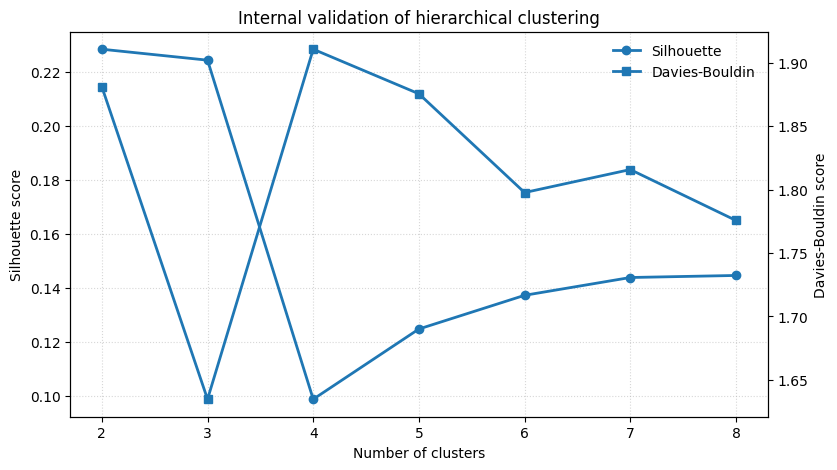

In [25]:
# ============================================================
# Comparación visual de métricas internas por número de clusters
# ============================================================

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    resultados_jerarquico["k"],
    resultados_jerarquico["silhouette"],
    marker="o",
    linewidth=2,
    label="Silhouette"
)

ax1.set_xlabel("Number of clusters")
ax1.set_ylabel("Silhouette score")
ax1.set_title("Internal validation of hierarchical clustering")
ax1.grid(True, linestyle=":", alpha=0.5)

ax2 = ax1.twinx()

ax2.plot(
    resultados_jerarquico["k"],
    resultados_jerarquico["davies_bouldin"],
    marker="s",
    linewidth=2,
    label="Davies-Bouldin"
)

ax2.set_ylabel("Davies-Bouldin score")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best",
    frameon=False
)

plt.show()

In [26]:
# ============================================================
# Asignación de clusters jerárquicos para k=2 y k=3
# ============================================================

from sklearn.cluster import AgglomerativeClustering

# ------------------------------------------------------------
# Ajuste de soluciones candidatas
# ------------------------------------------------------------

modelo_jerarquico_k2 = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

modelo_jerarquico_k3 = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

df_clustering["cluster_jerarquico_k2"] = modelo_jerarquico_k2.fit_predict(X_clustering)
df_clustering["cluster_jerarquico_k3"] = modelo_jerarquico_k3.fit_predict(X_clustering)

# ------------------------------------------------------------
# Tamaño absoluto y relativo de clusters
# ------------------------------------------------------------

resumen_tamanos_k2 = (
    df_clustering["cluster_jerarquico_k2"]
    .value_counts()
    .sort_index()
    .reset_index()
)

resumen_tamanos_k2.columns = ["cluster", "n_artistas"]
resumen_tamanos_k2["pct_artistas"] = (
    resumen_tamanos_k2["n_artistas"] / len(df_clustering) * 100
).round(2)

resumen_tamanos_k3 = (
    df_clustering["cluster_jerarquico_k3"]
    .value_counts()
    .sort_index()
    .reset_index()
)

resumen_tamanos_k3.columns = ["cluster", "n_artistas"]
resumen_tamanos_k3["pct_artistas"] = (
    resumen_tamanos_k3["n_artistas"] / len(df_clustering) * 100
).round(2)

display(resumen_tamanos_k2)
display(resumen_tamanos_k3)

,cluster,n_artistas,pct_artistas
0,0,2693,38.47
1,1,4307,61.53


,cluster,n_artistas,pct_artistas
0,0,4307,61.53
1,1,2484,35.49
2,2,209,2.99


In [27]:
# ============================================================
# Perfil digital de clusters jerárquicos k=3
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Variable de cluster a analizar
# ------------------------------------------------------------

cluster_col = "cluster_jerarquico_k3"

# ------------------------------------------------------------
# Resumen de métricas digitales originales por cluster
# Se usan medianas porque las variables son asimétricas
# ------------------------------------------------------------

perfil_clusters_k3 = (
    df_clustering
    .groupby(cluster_col)[variables_clustering_digitales_base]
    .median()
    .round(2)
)

# ------------------------------------------------------------
# Tamaño de cada cluster
# ------------------------------------------------------------

tamanos_clusters_k3 = (
    df_clustering[cluster_col]
    .value_counts()
    .sort_index()
    .rename("n_artistas")
)

perfil_clusters_k3.insert(
    0,
    "n_artistas",
    tamanos_clusters_k3
)

perfil_clusters_k3

,n_artistas,sp_monthly_listeners,sp_followers,deezer_fans,pandora_lifetime_streams,num_sp_playlists,num_am_playlists,num_yt_editorial_playlists,ins_followers,twitter_followers,tiktok_followers,tiktok_top_video_comments,ycs_views
cluster_jerarquico_k3,,,,,,,,,,,,,
0,4307,4092975.0,1316005.0,20667.0,50932989.0,151667.0,136.0,7.0,957201.0,91793.0,406000.0,1238051.0,526107536.0
1,2484,2346624.5,479098.5,4001.0,5555961.0,67815.0,62.0,3.0,74616.5,737.5,0.0,318377.5,64619895.0
2,209,2977.0,5976.0,74.0,0.0,469.0,0.0,0.0,1164744.0,0.0,3300000.0,910.0,40368323.0


In [28]:
# ============================================================
# Perfil de flags de faltante por cluster jerárquico k=3
# ============================================================

cluster_col = "cluster_jerarquico_k3"

# ------------------------------------------------------------
# Promedio de flags por cluster
# En variables binarias, el promedio equivale a proporción
# ------------------------------------------------------------

perfil_missing_k3 = (
    df_clustering
    .groupby(cluster_col)[missing_cols_clustering]
    .mean()
    .mul(100)
    .round(2)
)

# ------------------------------------------------------------
# Tamaño de cada cluster
# ------------------------------------------------------------

tamanos_clusters_k3 = (
    df_clustering[cluster_col]
    .value_counts()
    .sort_index()
    .rename("n_artistas")
)

perfil_missing_k3.insert(
    0,
    "n_artistas",
    tamanos_clusters_k3
)

perfil_missing_k3

,n_artistas,missing_tiktok_followers,missing_twitter_followers,missing_ins_followers,missing_ycs_views
cluster_jerarquico_k3,,,,,
0,4307,1.51,13.42,0.02,0.12
1,2484,83.37,42.23,22.83,22.42
2,209,30.14,69.86,18.18,27.27


# clustering jerarquico SIN FLAGS

In [29]:
# ============================================================
# Matriz de clustering sin flags de faltante
# ============================================================

X_clustering_sin_flags = X_clustering[variables_log_clustering].copy()

print("Filas:", X_clustering_sin_flags.shape[0])
print("Columnas:", X_clustering_sin_flags.shape[1])
print("Nulos:", X_clustering_sin_flags.isna().sum().sum())

Filas: 7000
Columnas: 12
Nulos: 0


In [30]:
# ============================================================
# Modelo jerárquico sin flags: evaluación de k
# ============================================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

rango_k = range(2, 9)

resultados_jerarquico_sin_flags = []

for k in rango_k:
    
    modelo = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    etiquetas = modelo.fit_predict(X_clustering_sin_flags)
    
    resultados_jerarquico_sin_flags.append({
        "k": k,
        "silhouette": silhouette_score(X_clustering_sin_flags, etiquetas),
        "davies_bouldin": davies_bouldin_score(X_clustering_sin_flags, etiquetas),
        "calinski_harabasz": calinski_harabasz_score(X_clustering_sin_flags, etiquetas),
        "n_clusters_obtenidos": len(set(etiquetas))
    })

resultados_jerarquico_sin_flags = pd.DataFrame(resultados_jerarquico_sin_flags)

resultados_jerarquico_sin_flags.round(4)

,k,silhouette,davies_bouldin,calinski_harabasz,n_clusters_obtenidos
0,2,0.3150,1.6845,2032.4171,2
1,3,0.2951,1.5024,1515.9215,3
2,4,0.1285,1.9420,1324.7902,4
3,5,0.1482,1.8211,1265.3431,5
4,6,0.1204,1.7221,1165.3071,6
5,7,0.1304,1.7201,1095.8359,7
6,8,0.1142,1.6939,1045.4831,8


In [31]:
# ============================================================
# Etiquetas jerárquicas sin flags para k=2 y k=3
# ============================================================

modelo_sin_flags_k2 = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

modelo_sin_flags_k3 = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

df_clustering["cluster_jerarquico_sin_flags_k2"] = modelo_sin_flags_k2.fit_predict(
    X_clustering_sin_flags
)

df_clustering["cluster_jerarquico_sin_flags_k3"] = modelo_sin_flags_k3.fit_predict(
    X_clustering_sin_flags
)

resumen_tamanos_sin_flags_k2 = (
    df_clustering["cluster_jerarquico_sin_flags_k2"]
    .value_counts()
    .sort_index()
    .reset_index()
)

resumen_tamanos_sin_flags_k2.columns = ["cluster", "n_artistas"]
resumen_tamanos_sin_flags_k2["pct_artistas"] = (
    resumen_tamanos_sin_flags_k2["n_artistas"] / len(df_clustering) * 100
).round(2)

resumen_tamanos_sin_flags_k3 = (
    df_clustering["cluster_jerarquico_sin_flags_k3"]
    .value_counts()
    .sort_index()
    .reset_index()
)

resumen_tamanos_sin_flags_k3.columns = ["cluster", "n_artistas"]
resumen_tamanos_sin_flags_k3["pct_artistas"] = (
    resumen_tamanos_sin_flags_k3["n_artistas"] / len(df_clustering) * 100
).round(2)

display(resumen_tamanos_sin_flags_k2)
display(resumen_tamanos_sin_flags_k3)

,cluster,n_artistas,pct_artistas
0,0,1725,24.64
1,1,5275,75.36


,cluster,n_artistas,pct_artistas
0,0,5275,75.36
1,1,1614,23.06
2,2,111,1.59


In [32]:
# ============================================================
# Perfil digital de clusters jerárquicos sin flags
# k=2 y k=3
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Función para resumir perfiles por cluster
# ------------------------------------------------------------

def perfilar_clusters(df_base, cluster_col, variables_base):
    
    tamanos = (
        df_base[cluster_col]
        .value_counts()
        .sort_index()
        .rename("n_artistas")
    )
    
    perfil_medianas = (
        df_base
        .groupby(cluster_col)[variables_base]
        .median()
        .round(2)
    )
    
    perfil_medianas.insert(
        0,
        "n_artistas",
        tamanos
    )
    
    mediana_general = df_base[variables_base].median()
    
    perfil_relativo = (
        (perfil_medianas[variables_base] + 1)
        .div(mediana_general + 1, axis=1)
        .round(2)
    )
    
    perfil_relativo.insert(
        0,
        "n_artistas",
        tamanos
    )
    
    return perfil_medianas, perfil_relativo

# ------------------------------------------------------------
# Perfiles para k=2
# ------------------------------------------------------------

perfil_k2_medianas, perfil_k2_relativo = perfilar_clusters(
    df_base=df_clustering,
    cluster_col="cluster_jerarquico_sin_flags_k2",
    variables_base=variables_clustering_digitales_base
)

# ------------------------------------------------------------
# Perfiles para k=3
# ------------------------------------------------------------

perfil_k3_medianas, perfil_k3_relativo = perfilar_clusters(
    df_base=df_clustering,
    cluster_col="cluster_jerarquico_sin_flags_k3",
    variables_base=variables_clustering_digitales_base
)

print("Perfil k=2 | Medianas originales")
display(perfil_k2_medianas)

print("Perfil k=2 | Razón contra mediana general")
display(perfil_k2_relativo)

print("Perfil k=3 | Medianas originales")
display(perfil_k3_medianas)

print("Perfil k=3 | Razón contra mediana general")
display(perfil_k3_relativo)

Perfil k=2 | Medianas originales


,n_artistas,sp_monthly_listeners,sp_followers,deezer_fans,pandora_lifetime_streams,num_sp_playlists,num_am_playlists,num_yt_editorial_playlists,ins_followers,twitter_followers,tiktok_followers,tiktok_top_video_comments,ycs_views
cluster_jerarquico_sin_flags_k2,,,,,,,,,,,,,
0,1725,1479288.0,175708.0,894.0,16678.0,29342.0,26.0,1.0,38409.0,0.0,0.0,151114.0,4463161.0
1,5275,3711038.0,1201066.0,22982.0,66828061.0,142116.0,132.0,7.0,723040.0,68820.0,180800.0,1007921.0,431498351.0


Perfil k=2 | Razón contra mediana general


,n_artistas,sp_monthly_listeners,sp_followers,deezer_fans,pandora_lifetime_streams,num_sp_playlists,num_am_playlists,num_yt_editorial_playlists,ins_followers,twitter_followers,tiktok_followers,tiktok_top_video_comments,ycs_views
cluster_jerarquico_sin_flags_k2,,,,,,,,,,,,,
0,1725,0.47,0.19,0.1,0.0,0.27,0.27,0.33,0.07,0.0,0.0,0.22,0.02
1,5275,1.18,1.31,2.46,2.95,1.3,1.32,1.33,1.39,2.48,1.69,1.45,1.48


Perfil k=3 | Medianas originales


,n_artistas,sp_monthly_listeners,sp_followers,deezer_fans,pandora_lifetime_streams,num_sp_playlists,num_am_playlists,num_yt_editorial_playlists,ins_followers,twitter_followers,tiktok_followers,tiktok_top_video_comments,ycs_views
cluster_jerarquico_sin_flags_k3,,,,,,,,,,,,,
0,5275,3711038.0,1201066.0,22982.0,66828061.0,142116.0,132.0,7.0,723040.0,68820.0,180800.0,1007921.0,431498351.0
1,1614,1662988.0,215697.5,1137.0,29491.0,32291.0,30.0,1.0,37775.0,0.0,0.0,183465.0,4826336.5
2,111,86.0,448.0,2.0,0.0,79.0,0.0,0.0,140761.0,0.0,1200000.0,1.0,470024.0


Perfil k=3 | Razón contra mediana general


,n_artistas,sp_monthly_listeners,sp_followers,deezer_fans,pandora_lifetime_streams,num_sp_playlists,num_am_playlists,num_yt_editorial_playlists,ins_followers,twitter_followers,tiktok_followers,tiktok_top_video_comments,ycs_views
cluster_jerarquico_sin_flags_k3,,,,,,,,,,,,,
0,5275,1.18,1.31,2.46,2.95,1.3,1.32,1.33,1.39,2.48,1.69,1.45,1.48
1,1614,0.53,0.24,0.12,0.0,0.3,0.31,0.33,0.07,0.0,0.0,0.26,0.02
2,111,0.0,0.0,0.0,0.0,0.0,0.01,0.17,0.27,0.0,11.21,0.00,0.0


In [33]:
# ============================================================
# Control de faltantes por cluster en solución jerárquica sin flags
# ============================================================

cluster_cols_a_revisar = [
    "cluster_jerarquico_sin_flags_k2",
    "cluster_jerarquico_sin_flags_k3"
]

for cluster_col in cluster_cols_a_revisar:
    
    print(f"\nPerfil de faltantes para {cluster_col}")
    
    perfil_missing = (
        df_clustering
        .groupby(cluster_col)[missing_cols_clustering]
        .mean()
        .mul(100)
        .round(2)
    )
    
    tamanos = (
        df_clustering[cluster_col]
        .value_counts()
        .sort_index()
        .rename("n_artistas")
    )
    
    perfil_missing.insert(
        0,
        "n_artistas",
        tamanos
    )
    
    display(perfil_missing)


Perfil de faltantes para cluster_jerarquico_sin_flags_k2


,n_artistas,missing_tiktok_followers,missing_twitter_followers,missing_ins_followers,missing_ycs_views
cluster_jerarquico_sin_flags_k2,,,,,
0,1725,59.59,55.19,35.13,35.42
1,5275,22.20,15.56,0.00,0.15



Perfil de faltantes para cluster_jerarquico_sin_flags_k3


,n_artistas,missing_tiktok_followers,missing_twitter_followers,missing_ins_followers,missing_ycs_views
cluster_jerarquico_sin_flags_k3,,,,,
0,5275,22.20,15.56,0.00,0.15
1,1614,60.59,54.03,35.19,35.01
2,111,45.05,72.07,34.23,41.44


# clustering jerarquico sin tiktok y twitter followers
porque tienen mucho nulos 

Cluster 0: artistas con alta consolidación digital

Agrupa 6284 artistas, el 89,8% del dataset. Está por encima de la mediana general en todas las variables activas, aunque no de manera extrema. Tiene mayor presencia en Spotify, playlists, Deezer, Pandora, Instagram, TikTok engagement y YouTube.

Interpretación inicial posible:

Artistas con ecosistema digital consolidado y señales activas en múltiples plataformas.

Cluster 1: artistas con baja consolidación digital

Agrupa 716 artistas, el 10,2% del dataset. Está muy por debajo de la mediana general en casi todas las variables. La diferencia es muy marcada en Spotify, Deezer, Pandora, playlists, TikTok comments y YouTube.

In [34]:
# ============================================================
# Matriz alternativa sin variables con mayor proporción de nulos
# ============================================================

variables_clustering_digitales_sin_nulos_altos = [
    # Streaming
    "sp_monthly_listeners",
    "sp_followers",
    "deezer_fans",
    "pandora_lifetime_streams",

    # Playlists
    "num_sp_playlists",
    "num_am_playlists",
    "num_yt_editorial_playlists",

    # Redes sociales
    "ins_followers",
    "tiktok_top_video_comments",

    # YouTube
    "ycs_views"
]

variables_clustering_digitales_sin_nulos_altos = [
    col for col in variables_clustering_digitales_sin_nulos_altos
    if col in df.columns
]

df_clustering_alt = df.copy()

df_clustering_alt[variables_clustering_digitales_sin_nulos_altos] = (
    df_clustering_alt[variables_clustering_digitales_sin_nulos_altos]
    .fillna(0)
)

variables_log_clustering_alt = []

for col in variables_clustering_digitales_sin_nulos_altos:
    col_log = f"log1p_{col}"
    df_clustering_alt[col_log] = np.log1p(df_clustering_alt[col].astype(float))
    variables_log_clustering_alt.append(col_log)

scaler_clustering_alt = StandardScaler()

X_clustering_alt = pd.DataFrame(
    scaler_clustering_alt.fit_transform(df_clustering_alt[variables_log_clustering_alt]),
    columns=variables_log_clustering_alt,
    index=df_clustering_alt.index
)

print("Filas:", X_clustering_alt.shape[0])
print("Columnas:", X_clustering_alt.shape[1])
print("Nulos:", X_clustering_alt.isna().sum().sum())

Filas: 7000
Columnas: 10
Nulos: 0


In [36]:
# ============================================================
# Modelo jerárquico alternativo: evaluación de k
# ============================================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

rango_k = range(2, 9)

resultados_jerarquico_alt = []

for k in rango_k:
    
    modelo = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    etiquetas = modelo.fit_predict(X_clustering_alt)
    
    resultados_jerarquico_alt.append({
        "k": k,
        "silhouette": silhouette_score(X_clustering_alt, etiquetas),
        "davies_bouldin": davies_bouldin_score(X_clustering_alt, etiquetas),
        "calinski_harabasz": calinski_harabasz_score(X_clustering_alt, etiquetas),
        "n_clusters_obtenidos": len(set(etiquetas))
    })

resultados_jerarquico_alt = pd.DataFrame(resultados_jerarquico_alt)

resultados_jerarquico_alt.round(4)

,k,silhouette,davies_bouldin,calinski_harabasz,n_clusters_obtenidos
0,2,0.4523,1.1701,2375.4995,2
1,3,0.1794,1.3902,2088.5092,3
2,4,0.1938,1.6113,1824.9158,4
3,5,0.1981,1.5445,1685.8894,5
4,6,0.1527,1.6277,1535.9686,6
5,7,0.1653,1.5392,1445.2402,7
6,8,0.1247,1.6674,1365.1582,8


In [37]:
# ============================================================
# Etiquetas del modelo jerárquico alternativo con k=2
# ============================================================

from sklearn.cluster import AgglomerativeClustering

modelo_jerarquico_alt_k2 = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

df_clustering_alt["cluster_jerarquico_alt_k2"] = modelo_jerarquico_alt_k2.fit_predict(
    X_clustering_alt
)

# ------------------------------------------------------------
# Tamaño absoluto y relativo de clusters
# ------------------------------------------------------------

resumen_tamanos_alt_k2 = (
    df_clustering_alt["cluster_jerarquico_alt_k2"]
    .value_counts()
    .sort_index()
    .reset_index()
)

resumen_tamanos_alt_k2.columns = ["cluster", "n_artistas"]

resumen_tamanos_alt_k2["pct_artistas"] = (
    resumen_tamanos_alt_k2["n_artistas"] / len(df_clustering_alt) * 100
).round(2)

resumen_tamanos_alt_k2

,cluster,n_artistas,pct_artistas
0,0,6284,89.77
1,1,716,10.23


In [38]:
# ============================================================
# Perfil digital de clusters jerárquicos alternativos k=2
# ============================================================

cluster_col = "cluster_jerarquico_alt_k2"

# ------------------------------------------------------------
# Medianas originales por cluster
# ------------------------------------------------------------

perfil_alt_k2_medianas = (
    df_clustering_alt
    .groupby(cluster_col)[variables_clustering_digitales_sin_nulos_altos]
    .median()
    .round(2)
)

tamanos_alt_k2 = (
    df_clustering_alt[cluster_col]
    .value_counts()
    .sort_index()
    .rename("n_artistas")
)

perfil_alt_k2_medianas.insert(
    0,
    "n_artistas",
    tamanos_alt_k2
)

display(perfil_alt_k2_medianas)

# ------------------------------------------------------------
# Perfil relativo frente a la mediana general
# ------------------------------------------------------------

mediana_general_alt = (
    df_clustering_alt[variables_clustering_digitales_sin_nulos_altos]
    .median()
)

perfil_alt_k2_relativo = (
    (perfil_alt_k2_medianas[variables_clustering_digitales_sin_nulos_altos] + 1)
    .div(mediana_general_alt + 1, axis=1)
    .round(2)
)

perfil_alt_k2_relativo.insert(
    0,
    "n_artistas",
    tamanos_alt_k2
)

display(perfil_alt_k2_relativo)

,n_artistas,sp_monthly_listeners,sp_followers,deezer_fans,pandora_lifetime_streams,num_sp_playlists,num_am_playlists,num_yt_editorial_playlists,ins_followers,tiktok_top_video_comments,ycs_views
cluster_jerarquico_alt_k2,,,,,,,,,,,
0,6284,3464928.0,1086341.5,15945.5,45152841.5,124886.5,116.0,6.0,553629.5,844530.0,333384305.5
1,716,174646.0,42263.0,141.0,6.5,5194.0,4.0,0.0,105235.0,20222.5,7663364.0


,n_artistas,sp_monthly_listeners,sp_followers,deezer_fans,pandora_lifetime_streams,num_sp_playlists,num_am_playlists,num_yt_editorial_playlists,ins_followers,tiktok_top_video_comments,ycs_views
cluster_jerarquico_alt_k2,,,,,,,,,,,
0,6284,1.1,1.19,1.71,2.0,1.15,1.16,1.17,1.07,1.21,1.14
1,716,0.06,0.05,0.02,0.0,0.05,0.05,0.17,0.2,0.03,0.03


In [39]:
# ============================================================
# Control de faltantes por cluster en modelo alternativo k=2
# ============================================================

missing_cols_alt = [
    "ins_followers",
    "ycs_views"
]

missing_cols_alt = [
    col for col in missing_cols_alt
    if col in df.columns
]

df_missing_alt = df.copy()

for col in missing_cols_alt:
    df_missing_alt[f"missing_{col}"] = df_missing_alt[col].isna().astype(int)

missing_cols_alt_flags = [
    f"missing_{col}"
    for col in missing_cols_alt
]

perfil_missing_alt_k2 = (
    df_missing_alt
    .assign(cluster_jerarquico_alt_k2=df_clustering_alt["cluster_jerarquico_alt_k2"])
    .groupby("cluster_jerarquico_alt_k2")[missing_cols_alt_flags]
    .mean()
    .mul(100)
    .round(2)
)

perfil_missing_alt_k2.insert(
    0,
    "n_artistas",
    tamanos_alt_k2
)

perfil_missing_alt_k2

,n_artistas,missing_ins_followers,missing_ycs_views
cluster_jerarquico_alt_k2,,,
0,6284,6.44,6.09
1,716,28.07,32.96


In [40]:
# ============================================================
# Control de faltantes por cluster en modelo alternativo k=2
# ============================================================

missing_cols_alt = [
    "ins_followers",
    "ycs_views"
]

missing_cols_alt = [
    col for col in missing_cols_alt
    if col in df.columns
]

df_missing_alt = df.copy()

for col in missing_cols_alt:
    df_missing_alt[f"missing_{col}"] = df_missing_alt[col].isna().astype(int)

missing_cols_alt_flags = [
    f"missing_{col}"
    for col in missing_cols_alt
]

perfil_missing_alt_k2 = (
    df_missing_alt
    .assign(cluster_jerarquico_alt_k2=df_clustering_alt["cluster_jerarquico_alt_k2"])
    .groupby("cluster_jerarquico_alt_k2")[missing_cols_alt_flags]
    .mean()
    .mul(100)
    .round(2)
)

perfil_missing_alt_k2.insert(
    0,
    "n_artistas",
    tamanos_alt_k2
)

perfil_missing_alt_k2

,n_artistas,missing_ins_followers,missing_ycs_views
cluster_jerarquico_alt_k2,,,
0,6284,6.44,6.09
1,716,28.07,32.96


In [41]:
# ============================================================
# Coeficiente cofenético y dendrograma
# Modelo jerárquico alternativo
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import pdist

# ------------------------------------------------------------
# Cálculo de distancias euclídeas sobre la matriz alternativa
# ------------------------------------------------------------

distancias_alt = pdist(
    X_clustering_alt,
    metric="euclidean"
)

# ------------------------------------------------------------
# Linkage jerárquico con método Ward
# ------------------------------------------------------------

linkage_alt = linkage(
    distancias_alt,
    method="ward"
)

# ------------------------------------------------------------
# Coeficiente cofenético
# ------------------------------------------------------------

coeficiente_cofenetico_alt, distancias_cofeneticas_alt = cophenet(
    linkage_alt,
    distancias_alt
)

print("Coeficiente cofenético:", round(coeficiente_cofenetico_alt, 4))

Coeficiente cofenético: 0.6347


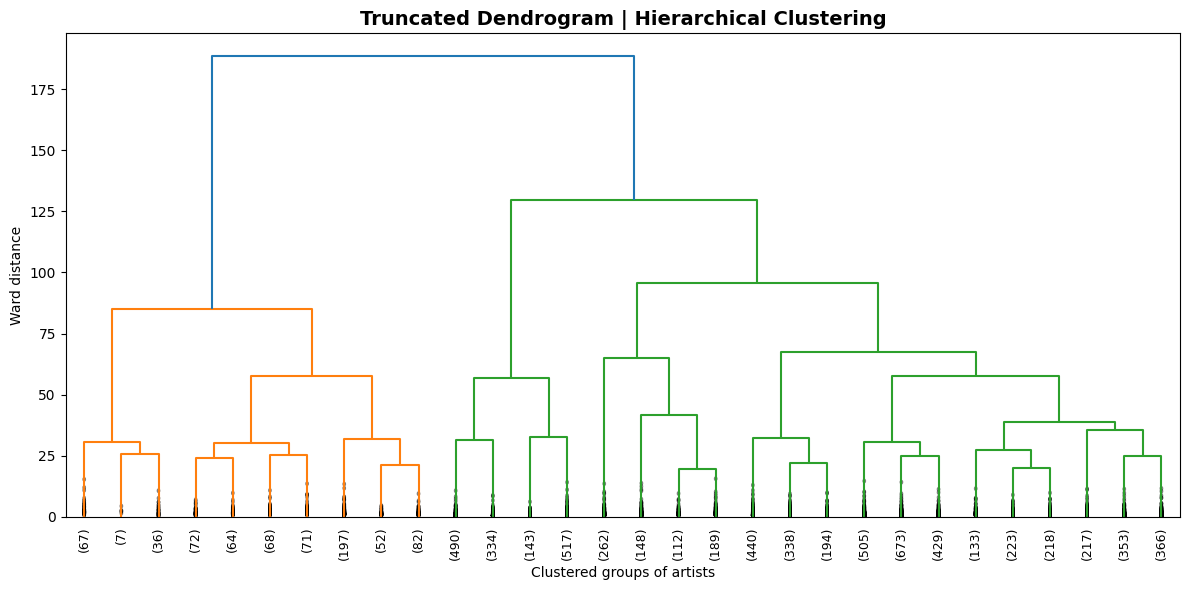

In [42]:
# ============================================================
# Dendrograma truncado
# Modelo jerárquico alternativo
# ============================================================

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_alt,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True
)

plt.title(
    "Truncated Dendrogram | Hierarchical Clustering",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Clustered groups of artists")
plt.ylabel("Ward distance")

plt.tight_layout()
plt.show()

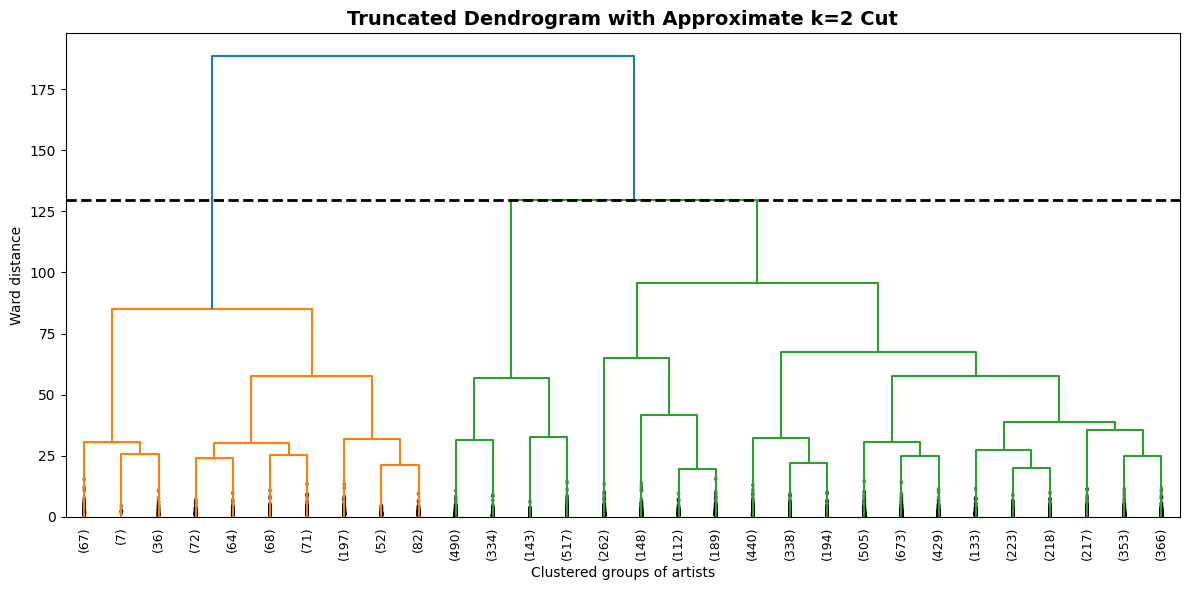

Altura aproximada de corte para k=2: 129.8242


In [43]:
# ============================================================
# Dendrograma truncado con línea de corte aproximada para k=2
# ============================================================

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_alt,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True
)

# ------------------------------------------------------------
# Altura de corte aproximada para obtener k=2
# ------------------------------------------------------------

altura_corte_k2 = linkage_alt[-2, 2]

plt.axhline(
    y=altura_corte_k2,
    linestyle="--",
    linewidth=2,
    color="black"
)

plt.title(
    "Truncated Dendrogram with Approximate k=2 Cut",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Clustered groups of artists")
plt.ylabel("Ward distance")

plt.tight_layout()
plt.show()

print("Altura aproximada de corte para k=2:", round(altura_corte_k2, 4))

## clusters segun metadata

In [44]:
# ============================================================
# Perfil de clusters con metadata
# Modelo jerárquico alternativo k=2
# ============================================================

import pandas as pd
import numpy as np

cluster_col = "cluster_jerarquico_alt_k2"

metadata_cols_para_perfil = [
    "country_short",
    "genre_short",
    "pronoun_short",
    "band",
    "major_record_label"
]

metadata_cols_para_perfil = [
    col for col in metadata_cols_para_perfil
    if col in df_clustering_alt.columns
]

# ------------------------------------------------------------
# Función para calcular distribución porcentual por cluster
# ------------------------------------------------------------

def distribucion_metadata_por_cluster(df_base, cluster_col, variable):
    
    tabla = (
        pd.crosstab(
            df_base[cluster_col],
            df_base[variable],
            normalize="index"
        )
        .mul(100)
        .round(2)
    )
    
    tabla.insert(
        0,
        "n_artistas",
        df_base[cluster_col].value_counts().sort_index()
    )
    
    return tabla

# ------------------------------------------------------------
# Distribuciones por variable metadata
# ------------------------------------------------------------

perfiles_metadata = {}

for variable in metadata_cols_para_perfil:
    
    print(f"\nDistribución de {variable} por cluster")
    
    tabla_variable = distribucion_metadata_por_cluster(
        df_base=df_clustering_alt,
        cluster_col=cluster_col,
        variable=variable
    )
    
    perfiles_metadata[variable] = tabla_variable
    
    display(tabla_variable)


Distribución de country_short por cluster


country_short,n_artistas,Africa & ME,Asia & Oceania,Europe_sinGB,Great Britain,LATAM,North America
cluster_jerarquico_alt_k2,,,,,,,
0,6284,4.73,11.05,14.87,10.52,17.45,41.39
1,716,6.27,29.10,14.78,6.12,14.48,29.25



Distribución de genre_short por cluster


genre_short,n_artistas,Alternative & indie,Country & folk,Electronic & dance,Hip-hop & trap,Jazz & blues & classical,Latin & urban,Miscellaneous,Pop,"R&b, soul & funk",Regional global,Regional mexicano,Rock & metal
cluster_jerarquico_alt_k2,,,,,,,,,,,,,
0,6284,6.48,4.34,12.60,13.08,2.53,10.25,1.86,20.37,7.43,8.88,3.50,8.67
1,716,7.54,0.84,18.85,14.11,2.93,10.06,4.47,21.65,3.77,11.17,1.54,3.07



Distribución de pronoun_short por cluster


pronoun_short,n_artistas,Non-Binary/Diverse,he/him,she/her,they/them
cluster_jerarquico_alt_k2,,,,,
0,6284,0.19,52.69,18.79,28.33
1,716,0.14,53.49,27.79,18.58



Distribución de band por cluster


band,n_artistas,False,True
cluster_jerarquico_alt_k2,,,
0,6284,70.11,29.89
1,716,80.17,19.83



Distribución de major_record_label por cluster


major_record_label,n_artistas,False,True
cluster_jerarquico_alt_k2,,,
0,6284,71.77,28.23
1,716,90.45,9.55


In [45]:
# ============================================================
# Categorías principales de metadata por cluster
# ============================================================

top_metadata_por_cluster = []

for variable in metadata_cols_para_perfil:
    
    tabla_abs = (
        pd.crosstab(
            df_clustering_alt[cluster_col],
            df_clustering_alt[variable]
        )
    )
    
    tabla_pct = (
        pd.crosstab(
            df_clustering_alt[cluster_col],
            df_clustering_alt[variable],
            normalize="index"
        )
        .mul(100)
    )
    
    for cluster in tabla_abs.index:
        
        categorias_ordenadas = (
            tabla_pct
            .loc[cluster]
            .sort_values(ascending=False)
            .head(3)
        )
        
        for categoria, pct in categorias_ordenadas.items():
            
            top_metadata_por_cluster.append({
                "variable": variable,
                "cluster": cluster,
                "categoria": categoria,
                "pct_cluster": round(pct, 2),
                "n_artistas_categoria_cluster": int(tabla_abs.loc[cluster, categoria])
            })

top_metadata_por_cluster = pd.DataFrame(top_metadata_por_cluster)

top_metadata_por_cluster

,variable,cluster,categoria,pct_cluster,n_artistas_categoria_cluster
0,country_short,0,North America,41.39,2592
1,country_short,0,LATAM,17.45,1093
2,country_short,0,Europe_sinGB,14.87,931
3,country_short,1,North America,29.25,196
4,country_short,1,Asia & Oceania,29.10,195
5,country_short,1,Europe_sinGB,14.78,99
6,genre_short,0,Pop,20.37,1280
7,genre_short,0,Hip-hop & trap,13.08,822
8,genre_short,0,Electronic & dance,12.60,792
9,genre_short,1,Pop,21.65,155


## cruce con conciertos

In [46]:
# ============================================================
# Cruce entre clusters digitales y actividad en vivo
# Modelo principal sobre dataset_7000
# ============================================================

cluster_col = "cluster_jerarquico_alt_k2"
target = "n_shows_24_25"

# ------------------------------------------------------------
# Disponibilidad de target por cluster
# ------------------------------------------------------------

disponibilidad_target_por_cluster = (
    df_clustering_alt
    .groupby(cluster_col)[target]
    .agg(
        n_artistas="size",
        n_con_target="count",
        n_sin_target=lambda x: x.isna().sum()
    )
)

disponibilidad_target_por_cluster["pct_con_target"] = (
    disponibilidad_target_por_cluster["n_con_target"] /
    disponibilidad_target_por_cluster["n_artistas"] * 100
).round(2)

display(disponibilidad_target_por_cluster)

# ------------------------------------------------------------
# Subset con target disponible
# ------------------------------------------------------------

df_cluster_live = (
    df_clustering_alt
    .dropna(subset=[target])
    .copy()
)

# ------------------------------------------------------------
# Resumen de actividad live por cluster
# ------------------------------------------------------------

resumen_live_por_cluster = (
    df_cluster_live
    .groupby(cluster_col)[target]
    .agg(
        n_artistas="size",
        media="mean",
        mediana="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90),
        maximo="max"
    )
    .round(2)
)

display(resumen_live_por_cluster)

,n_artistas,n_con_target,n_sin_target,pct_con_target
cluster_jerarquico_alt_k2,,,,
0,6284,4747,1537,75.54
1,716,166,550,23.18


,n_artistas,media,mediana,p75,p90,maximo
cluster_jerarquico_alt_k2,,,,,,
0,4747,24.9,13.0,39.0,69.0,179
1,166,7.07,2.0,8.0,19.5,139


In [47]:
# ============================================================
# Proporción de artistas con cero shows por cluster
# ============================================================

cero_shows_por_cluster = (
    df_cluster_live
    .assign(tiene_cero_shows=df_cluster_live[target] == 0)
    .groupby(cluster_col)["tiene_cero_shows"]
    .agg(
        n_artistas="size",
        n_cero_shows="sum",
        pct_cero_shows="mean"
    )
)

cero_shows_por_cluster["pct_cero_shows"] = (
    cero_shows_por_cluster["pct_cero_shows"] * 100
).round(2)

display(cero_shows_por_cluster)

,n_artistas,n_cero_shows,pct_cero_shows
cluster_jerarquico_alt_k2,,,
0,4747,804,16.94
1,166,56,33.73


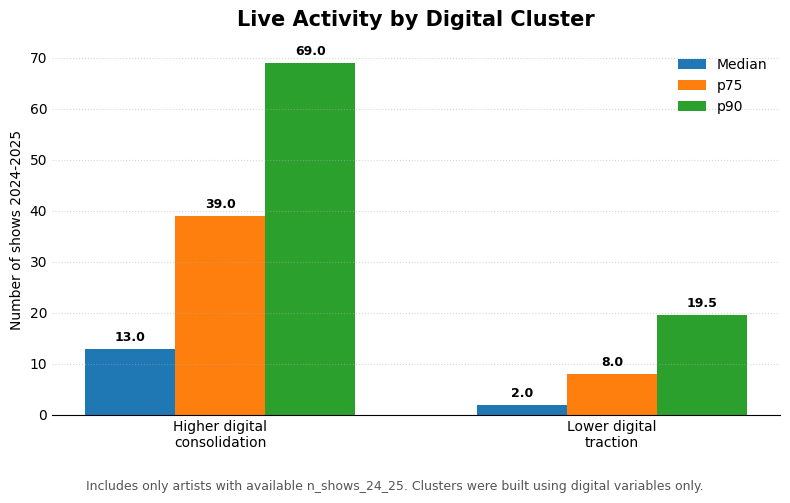

In [49]:
# ============================================================
# Gráfico de actividad en vivo por cluster digital
# Mediana, p75 y p90 de n_shows_24_25
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Datos de resumen
# ------------------------------------------------------------

cluster_col = "cluster_jerarquico_alt_k2"
target = "n_shows_24_25"

resumen_plot_live = (
    df_cluster_live
    .groupby(cluster_col)[target]
    .agg(
        mediana="median",
        p75=lambda x: x.quantile(0.75),
        p90=lambda x: x.quantile(0.90)
    )
    .round(2)
)

resumen_plot_live.index = [
    "Higher digital\nconsolidation",
    "Lower digital\ntraction"
]

# ------------------------------------------------------------
# Figura
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(resumen_plot_live.index))
width = 0.23

ax.bar(
    x - width,
    resumen_plot_live["mediana"],
    width,
    label="Median"
)

ax.bar(
    x,
    resumen_plot_live["p75"],
    width,
    label="p75"
)

ax.bar(
    x + width,
    resumen_plot_live["p90"],
    width,
    label="p90"
)

# ------------------------------------------------------------
# Etiquetas de valores
# ------------------------------------------------------------

for i, metric in enumerate(["mediana", "p75", "p90"]):
    offset = (i - 1) * width
    
    for j, value in enumerate(resumen_plot_live[metric]):
        ax.text(
            x[j] + offset,
            value + 1,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

# ------------------------------------------------------------
# Títulos y ejes
# ------------------------------------------------------------

ax.set_title(
    "Live Activity by Digital Cluster",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_ylabel("Number of shows 2024-2025")
ax.set_xticks(x)
ax.set_xticklabels(resumen_plot_live.index)

ax.legend(frameon=False)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.5
)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="both", length=0)

fig.text(
    0.5,
    0.01,
    "Includes only artists with available n_shows_24_25. Clusters were built using digital variables only.",
    ha="center",
    fontsize=9,
    color="#555555"
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

plt.show()